# SNR Analysis
@Author: Nyota Buduli Masirika

In [2]:
#packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from astropy.io import fits
from astropy import units as u
import os 
import scopesim as sim
#from astropy.wcs import WCS
from photutils.psf import EPSFBuilder, EPSFStar, EPSFStars, make_psf_model


In [3]:
#Changement of folder (needed to work with ScopeSim)
os.chdir("ScopeSim") #relative path to ScopeSim folder
print(os.getcwd())

c:\Users\Nyota\OneDrive - Universite de Liege\MASTER 3\TFE_AGN\Code\ScopeSim


## Functions and Variables
Codes to compile before continuing as the variables and functions are used in different parts of the notebook.

### i. Files

In [ ]:
file_circinus_pt_N_band = '../outputs/models/Circular_Gaussian_Circinus_N-band.fits'
file_circinus_pt_L_band = '../outputs/models/Elliptical_Gaussian_Circinus_L-band.fits'
file_extended_circinus_N_band = '../outputs/models/Pt_and_Extended_Gaussian_Circinus_N-band.fits'
file_real_circinus_N_band = '../data/N_band_Circinus.fits'
file_extended_without_psfsub = '../outputs/models/Elliptical_Gaussian_Circinus_extended_N-band.fits'

file_circinus_3_components_N_band = '../outputs/models/3_Pt_and_Extended_GaussianCircinus_N-band.fits'

psf_file_unres_077 = '../outputs/models/Circular_Gaussian_unres_pt_source_0.77Jy_N-band.fits'

### ii. Useful Variables

General variables linked to METIS, ScopeSim, etc.

In [ ]:
# Constants
L_band = 4 *u.um 
N_band = 12 *u.um 

# Variables linked to METIS
d_METIS = 39.3 * u.m # diameter of the primary mirror in the ELT

# Variables linked to ScopeSim
screen_size = 2048 # the size of the screen returned
screen_center = 1024 # the center of the source is located at the center of the screen
N_band_pixel_scale = 6.79 *u.mas # given by the header of the image generated by ScopeSim
L_band_pixel_scale = 0 *u.mas #! To change, not the good value

exptime_1hour = 3600 *u.s
exptime_1second = 1 *u.s

### iii. Mean Variance
Function to apply the error propagation formula to retrieve the mean Variance of an array:

$$\sigma_\text{mean}^2 = \frac{1}{N} \sigma_\text{tot}^2 = \frac{1}{N} \sum^N_i \sigma_i^2$$

where $N$ is the number of pixel in the subarray and the variance for a Poisson distribution is
$$\sigma^2 = \lambda * t$$
with $\lambda$ the rate at which the photons arrive and $t$ the integration time.

In [ ]:
def mean_Variance(rate, t):
    N = np.size(rate)
    return np.sum(rate)*t/N

### iv. Pc to mas converter
Function to convert the size in pc to the angular size in mas, using the distance to the source using:
$$\theta = 2 \arctan\left(\frac{S}{2D}\right)$$
with 
- $S$: the size in parsecs,
- $D$: the distance to the object in parsecs,
- $\theta$: the angular size in radians.

In [8]:
def pc_to_mas(D, S):
    """Convert the size of an object in pc to its angular size in mas using the distance to the source

    Args:
        D (Quantity): Distance between the source and the detector in pc
        S (Quantity): Size of the object in pc

    Returns:
        Quantity: Angular size of the object in mas
    """
    D = D.to(u.pc)
    S = S.to(u.pc)
    mas = 2*np.arctan(S/2/D)
    mas = mas.to(u.mas)
    return mas

## 1. SNR in N-band (no chop & nod)

Now that we can simulate observations with `ScopeSim`, an important thing to determine is the `Signal-to-noise ratio (SNR)`. Once more, we use the case of `Circinus`in the `N-band` before applying it to other objects and `L-band`. The image that we use is [Circular_Gaussian_Circinus_N-band.fits](./outputs/Circular_Gaussian_Circinus_N-band.fits). This is the initial image that we have generated in [3. Circunys FITS file](#3-circinus-fits-file) so before the observation with METIS.

### 1.1. Sky and object simulations

Before estimating the SNR of our source, we need to simulate observations of the sky and the object. We follow the same steps as in [4.1. N-band Observation of the source](#41-n-band-observation-of-the-source) but without the chop and nod technique.

The configuration is defined by instantiating a `UserCommands` object with a total requested exposure time is set to 3600s (1h).

In [ ]:
cmd = sim.UserCommands(use_instrument="METIS", set_modes=["img_n"], properties={"!OBS.exptime": exptime_1hour.value, "!OBS.dit": None, "!OBS.ndit": None})

In [ ]:
metis = sim.OpticalTrain(cmd)

#### 1.1.1. Blank sky observation

If we do not specify a source in the `observe` command, the blank sky will be observed.

In [ ]:
metis.observe()      # blank sky

astar.scopesim.optics.optical_train - Observing empty field


 FOVs: 100%|██████████| 3/3 [00:10<00:00,  3.51s/it]


By observing only the sky, we obtain the background signal `bg`.

astar.scopesim.effects.electronic - Detector mode set to high_capacity
astar.scopesim.effects.electronic - Requested exposure time: 3600.000 s
astar.scopesim.effects.electronic - Required DIT without saturation: 0.015 s
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 240820


astar.scopesim.effects.electronic - Total exposure time: 3600.000 s
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...
astar.scopesim.effects.electronic.electrons - Applying gain 201
astar.scopesim.effects.electronic.electrons - Applying digitization to dtype float32.
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 240820
astar.scopesim.effects.electronic - Total exposure time: 3600.000 s


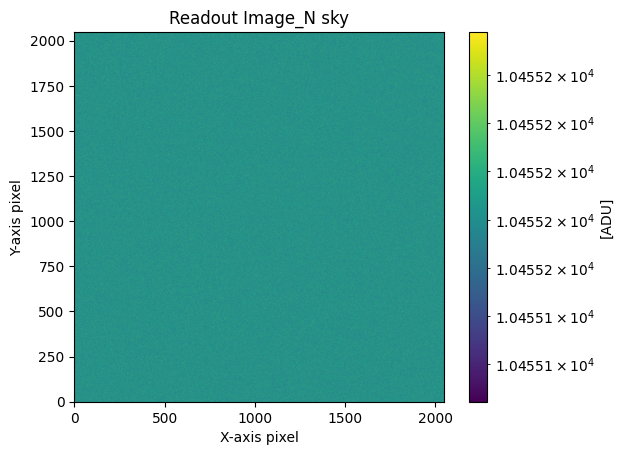

In [ ]:
bgresult = metis.readout(detector_readout_mode="auto", dit=None, ndit=None)[0] 
bgresult[1].data # [ADU]    
imskyraw=plt.imshow(bgresult[1].data, origin="lower", norm="log") 
plt.xlabel("X-axis pixel")
plt.ylabel("Y-axis pixel")
plt.title('Readout Image_N sky')
plt.colorbar(imskyraw, label='['+bgresult[1].header['BUNIT']+']')

`sky_implane` stand for the image of the sky before adding the effects of the detector. The `readout` method will add the detector effects introduced by the observation during the exposure time. 

In [ ]:
sky_implane = metis.image_planes[0].data # [ph/s]
sky_readout = metis.readout(exptime=exptime_1hour.value)[0]

astar.scopesim.effects.electronic - Requested exposure time: 3600.000 s
astar.scopesim.effects.electronic - Required DIT without saturation: 0.015 s
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 240820
astar.scopesim.effects.electronic - Total exposure time: 3600.000 s
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...
astar.scopesim.effects.electronic.electrons - Applying gain 201
astar.scopesim.effects.electronic.electrons - Applying digitization to dtype float32.
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 240820
astar.scopesim.effects.electronic - Total exposure time: 3600.000 s


Test to check if the `sky_implane` is really without any noise.

(np.float64(1.3709068298339844e-06), np.float64(140478122.32170653))

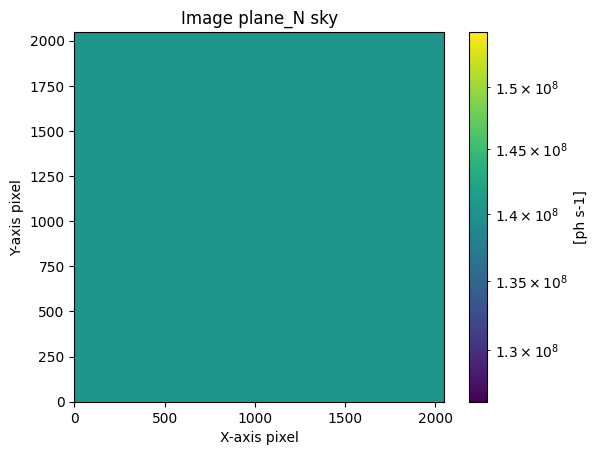

In [ ]:
imskyraw=plt.imshow(sky_implane, origin="lower", norm="log") 
plt.xlabel("X-axis pixel")
plt.ylabel("Y-axis pixel")
plt.title('Image plane_N sky')
plt.colorbar(imskyraw, label='['+metis.image_planes[0].header['BUNIT']+']')

np.std(sky_implane), np.mean(sky_implane)


We save the value of `dit` and `ndit` for later.

In [ ]:
# Save dit and ndit for later!
dit, ndit = metis.cmds["!OBS.dit"], metis.cmds["!OBS.ndit"]
print(dit, ndit)

0.014948924507931234 240820


#### 1.1.2. Object observation

Now that the blank sky has been observed, we can observe the object of interest (here Circinus).

In [ ]:
#with fits.open("AGN_sim_preparedCircinus.fits") as hdul:
with fits.open(file_circinus_pt_N_band) as hdul:
    src = sim.Source(image_hdu=hdul[0])

In [ ]:
metis.observe(src)

 FOVs: 100%|██████████| 3/3 [00:11<00:00,  3.91s/it]


As before, `src_implane` stand for the image of the object before adding the effects of the detector. The `readout` method will add the detector effects introduced by the observation during the exposure time. 

In [ ]:
src_implane = metis.image_planes[0].data # [ph/s]
header_src_implane = metis.image_planes[0].header
header_src_implane

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 2048                                                  
NAXIS2  =                 2048                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
WCSAXESD=                    2 / Number of coordinate axes                      
CRPIX1D =               1024.5 / Pixel coordinate of reference point            
CRPIX2D =               1024.5 / Pixel coordinate of reference point            
CDELT1D =                0.018 / [mm] Coordinate increment at reference point   
CDELT2D =                0.018 / [mm] Coordinate increment at reference point   
CUNIT1D = 'mm'              

Text(0.5, 1.0, 'Background substracted Implane image (with log norm)')

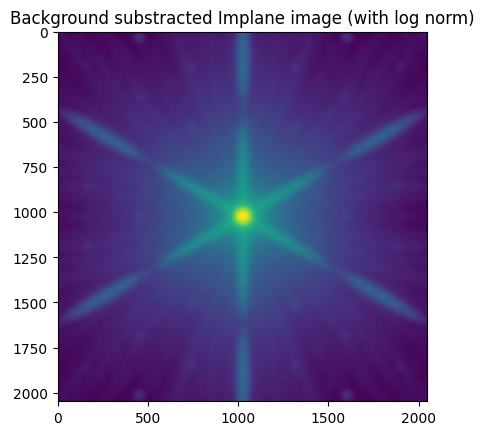

In [ ]:
plt.imshow(src_implane-sky_implane, norm='log')
plt.title('Background substracted Implane image (with log norm)')

In [ ]:
src_readout  = metis.readout(dit=dit, ndit=ndit)[0] 

astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 240820
astar.scopesim.effects.electronic - Total exposure time: 3600.000 s
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...
astar.scopesim.effects.electronic.electrons - Applying gain 201
astar.scopesim.effects.electronic.electrons - Applying digitization to dtype float32.
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 240820
astar.scopesim.effects.electronic - Total exposure time: 3600.000 s


In [ ]:
header_src_readout = src_readout[1].header
header_src_readout

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 2048                                                  
NAXIS2  =                 2048                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
WCSAXESD=                    2                                                  
CRPIX1D =              1024.5                                                   
CRPIX2D =              1024.5                                                   
CDELT1D =               0.018                                                   
CDELT2D =               0.018                                                   
CUNIT1D = 'mm      '        

We can plot the image of the object that METIS should give us. 

'\nlimits = 50\nplt.xlim(screen_center-limits,screen_center+limits)\nplt.ylim(screen_center-limits,screen_center+limits)'

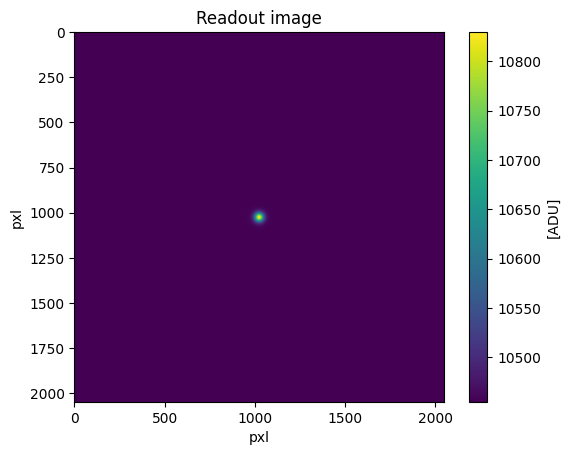

In [ ]:
imsrcraw=plt.imshow(src_readout[1].data)

plt.colorbar(imsrcraw, label='['+header_src_readout['BUNIT']+']')
plt.title('Readout image')
plt.xlabel('pxl')
plt.ylabel('pxl')
"""
limits = 50
plt.xlim(screen_center-limits,screen_center+limits)
plt.ylim(screen_center-limits,screen_center+limits)"""

`bgsub_readout` stands for the background-subtracted readout. The obtained image can be plotted with `norm=log` or not. We can see that without `norm=log` we can not see the difference between the background substracted image and the original one.

In [ ]:
bgsub_readout = src_readout[1].data - sky_readout[1].data #[ADU]

Text(0.5, 1.0, 'Background substracted readout image (with log norm)')

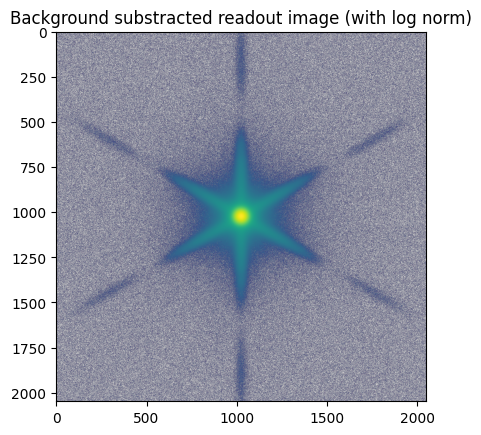

In [ ]:
plt.imshow(bgsub_readout, norm='log')
plt.title('Background substracted readout image (with log norm)')

Text(0, 0.5, 'pxl')

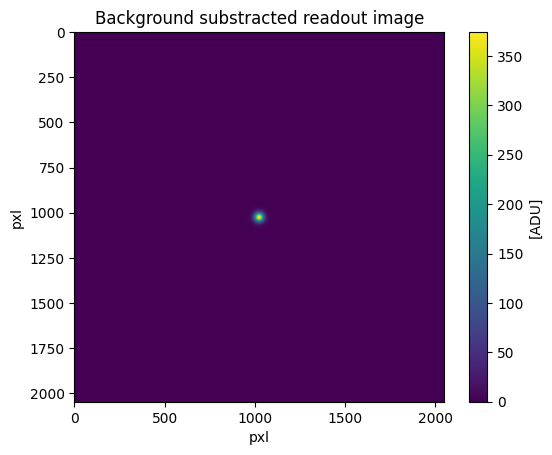

In [ ]:
imbgsub_readout=plt.imshow(bgsub_readout)
plt.colorbar(imbgsub_readout, label='['+header_src_readout['BUNIT']+']')
plt.title('Background substracted readout image')
plt.xlabel('pxl')
plt.ylabel('pxl')

#### 1.1.3. Detector informations
Collecting the information of the detector will be useful for the following calculations.

In [ ]:
metis.cmds["!DET"]

[0] mapping contents:
├─linearity:
│ ├─incident: [0, 2800000.0, 1e+99]
│ └─measured: [0, 2800000.0, 2800000.0]
├─mode: high_capacity
├─mindit: 0.011
├─full_well: 2800000.0
├─gain: 201
├─readout_noise: 300
└─dark_current: 100000.0

[1] mapping contents:
├─layout:
│ └─file_name: FPA_metis_img_n_geosnap_layout.dat
├─qe_curve:
│ └─file_name: QE_detector_geosnap.dat
├─linearity:
│ ├─file_name: FPA_linearity_HxRG.dat
│ ├─incident: [0, 2800000.0, 1e+99]
│ └─measured: [0, 2800000.0, 2800000.0]
├─detector: Teledyne GeoSnap
├─image_plane_id: 0
├─temperature: -240
├─dit: !OBS.dit
├─ndit: !OBS.ndit
├─mode: high_capacity
├─mindit: 0.011
├─full_well: 2800000.0
├─gain: 201
├─readout_noise: 300
└─dark_current: 100000.0

The units of `ron` come from the [online documentation](https://scopesim.readthedocs.io/en/stable/_autosummary/scopesim.effects.electronic.noise.BasicReadoutNoise.html) of ScopeSim for METIS. The Readout noise is defined as $\text{ron}*\sqrt{\text{NDIT}}$.

In [ ]:
ron = metis.cmds["!DET.readout_noise"] # [e-/integration^(1/2)]
ron

300

The unit of the `darkCurrent`comes from [Introduction_to_Scopesim_for_METIS.ipynb](./ScopeSim/inst_pkgs/METIS/docs/example_notebooks/Introduction_to_Scopesim_for_METIS.ipynb).

In [ ]:
darkCurrent = metis.cmds['!DET.dark_current'] # [e-/s]
darkCurrent

100000.0

The ``Quantum Efficiency (QE)`` measures an imaging sensor's ability to convert incoming photons into photoelectrons, typically expressed as a percentage, with higher values indicating greater sensitivity:
$$\text{Photon} * \text{QE} = \text{e-}$$

For the *Teledyne GeoSnap detector*, ``QE`` depends on the wavelength. For the N band it is equal to 80% as given in [QE_detector_geosnap.dat](./ScopeSim/inst_pkgs/METIS/QE_detector_geosnap.dat).

In [ ]:
QE = 0.8 # [-]

### 1.2. Expected SNR

The *expected SNR* follows the methodology presented in [Circinus-LSS_L-SNR-OC.ipynb](./Examples/Circinus-LSS_L-SNR-OC.ipynb). The formula used to estimate the SNR is close to the theoretical formula presented below but neglects the detector noise. For now, we keep this result for comparison but it is a bit redundant. 

To estimate the photons/electrons noise from the background image without considering the detector noise, we need `imageplane` of the sky and the source. 

In [ ]:
bgsub_implane = src_implane - sky_implane

Now, we can estimate the noise from the background image. The total number of electrons collected is `dit * ndit * imageplane`, the expected noise is the square root of that (applying Poisson statistics). If we only consider photon noise, we can work with that as all the scalings to reproduce the readout (dividing by `ndit`) apply to both the signal and the noise images. 


In [ ]:
snr_exp = dit * ndit * bgsub_implane*QE / np.sqrt(dit * ndit * src_implane*QE)
print(f"Maximum value of the expected SNR: {np.max(snr_exp):.2f}")

Maximum value of the expected SNR: 22384.54


Text(0, 0.5, 'pxl')

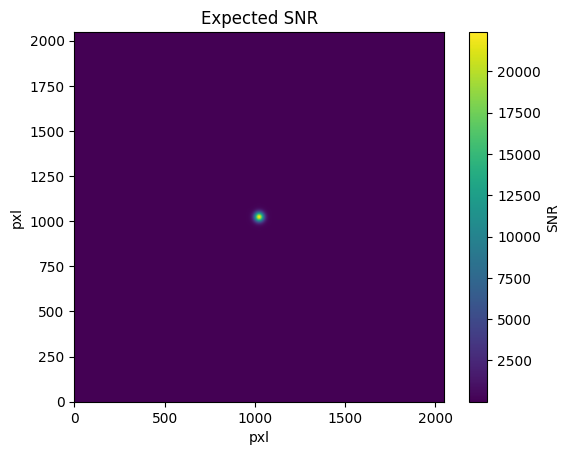

In [ ]:
plt.imshow(snr_exp, origin='lower')
plt.colorbar(label="SNR")
plt.title("Expected SNR")
plt.xlabel('pxl')
plt.ylabel('pxl')

### 1.3. Theoretical SNR

To estimate the photon and detector noise combined, we can use this theoretical formula.


![SNR formula](./images/SNR_formula.png)

The values of the parameters linked to the detector (the dark current `darkCurrent` and the read-out noise `ron`) were retrieved in Section [5.1.3. Detector Informations](#513-detector-informations).

Since all parameters are determined, we can apply the formula pixel per pixel to have an SNR map. 

In [ ]:
n_pix = 2048**2 
ron_per_pixel = ron/n_pix  # [e-/integration^(1/2)/pxl]
darkCurrent_per_pixel = darkCurrent/n_pix # [e-/s/pxl]
t = dit*ndit # [s]
snr_th = t * bgsub_implane*QE / np.sqrt(t * bgsub_implane*QE + sky_implane*QE*t + t*darkCurrent_per_pixel + ndit*ron_per_pixel**2)
print(f"Maximum value of the theoretical SNR: {np.max(snr_th):.2f}")

Maximum value of the theoretical SNR: 22384.54


Text(0, 0.5, 'pxl')

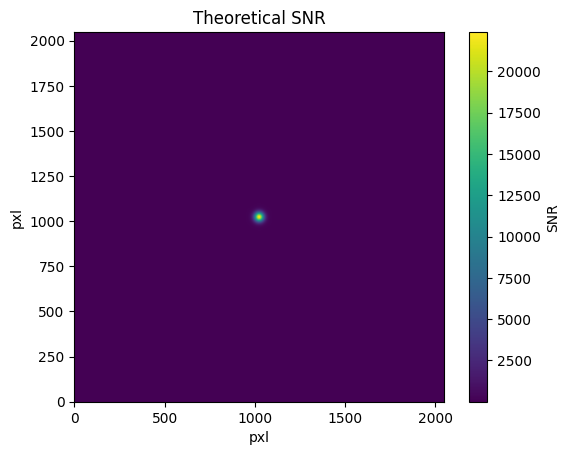

In [ ]:
plt.imshow(snr_th, origin='lower')
plt.colorbar(label="SNR")
plt.title("Theoretical SNR")
plt.xlabel('pxl')
plt.ylabel('pxl')

### 1.4. Estimating SNR from the data
To estimate the SNR from the data without the noiseless image `src_implane`, we can estimate it from the image after the detector readout `src_readout`. 
To do so, we select 2 areas: 
1. an area encircling the source with the less background possible `signal`,
2. an area with background only `bg_src`. 

With these areas, we can estimate the SNR thanks to:

$$\text{SNR} = \frac{t*\left[\text{Mean(Signal)} - \text{Mean(Background)}\right]}{\sqrt{\left(\sigma_{\text{mean,signal}}^2-\sigma_{\text{mean,background}}^2\right)+\sigma_{\text{mean,background}}^2}} = \frac{t*\left[\text{Mean(Signal)} - \text{Mean(Background)}\right]}{\sqrt{\sigma_{\text{mean,signal}}^2}}$$

To determine the mean variance of the subarray, we can use the error propagation formula with the assumption that the pixel variances are uncorrelated: 

$$\sigma_\text{mean}^2 = \frac{1}{N} \sigma_\text{tot}^2 = \frac{1}{N} \sum^N_i \sigma_i^2$$

where $N$ is the number of pixel in the subarray and the variance for a *Poisson distribution* is
$$\sigma^2 = \lambda * t$$
with $\lambda$ the rate at which the photons arrive and $t$ the integration time.

`/!\` As the `src_readout` is in **[ADU]**, we need to apply the `gain` **[e-/ADU]** to the image. 

In [ ]:
gain = metis.cmds["!DET.gain"] # [e-/ADU]
gain

201

In [ ]:
src_readout_data = src_readout[1].data *gain # [e-]


First, we select the two areas:

In [ ]:
# (y_start, y_end, x_start, x_end)
limits_source = 25
signal_coords = (screen_center-limits_source, screen_center+limits_source, screen_center-limits_source, screen_center+limits_source)
noise_coords = (screen_center-limits_source, screen_center+limits_source, 400-limits_source, 400+limits_source)

#Extract data from 
bg_src = src_readout_data[noise_coords[0]:noise_coords[1], noise_coords[2]:noise_coords[3]] 
signal=src_readout_data[signal_coords[0]:signal_coords[1], signal_coords[2]:signal_coords[3]] 

To be sure that they are well chosen, we can vizualise them:

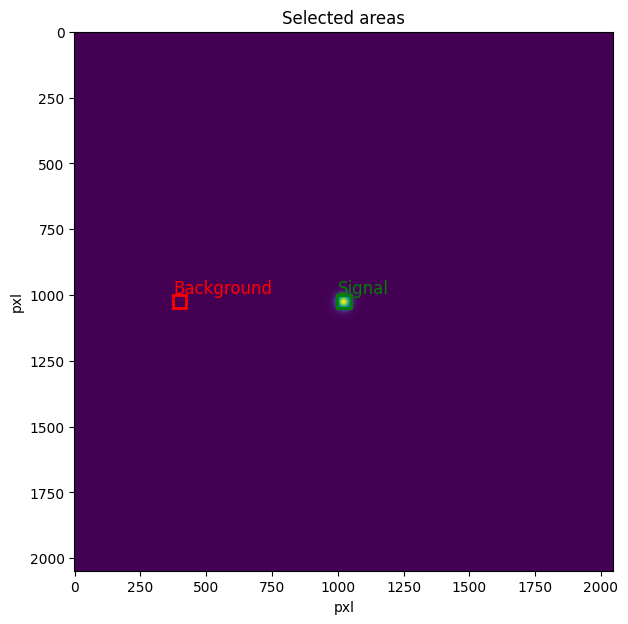

In [ ]:
# Create figure and axes
fig, ax = plt.subplots(1, figsize=(7, 7))

# Display the image
ax.imshow(src_readout_data)
ax.set_title("Selected areas")
ax.axis('on')

# Create a Rectangle patch for the Signal ROI (Green) - (x, y), width, height
rect_signal = patches.Rectangle((signal_coords[2], signal_coords[0]),
                                (signal_coords[3] - signal_coords[2]),
                                (signal_coords[1] - signal_coords[0]),
                                linewidth=2, edgecolor='g', facecolor='none')
ax.add_patch(rect_signal)
ax.text(signal_coords[2], signal_coords[0] - 5, 'Signal', color='g', fontsize=12)

# Create a Rectangle patch for the Background (Red)
rect_bg = patches.Rectangle((noise_coords[2], noise_coords[0]),
                            (noise_coords[3] - noise_coords[2]),
                            (noise_coords[1] - noise_coords[0]),
                            linewidth=2, edgecolor='r', facecolor='none')
ax.add_patch(rect_bg)
ax.text(noise_coords[2], noise_coords[0] - 5, 'Background', color='r', fontsize=12)
#cax = divider.append_axes('right', size='5%', pad=0.05)
#fig.colorbar(src_readout_data, cax=cax, orientation='vertical', label='['+header_src_readout['BUNIT']+']')
plt.xlabel('pxl')
plt.ylabel('pxl')
plt.show()

Secondly, we can apply the error propagation formula to retrieve the mean Variance of the subarray:

$$\sigma_\text{mean}^2 = \frac{1}{N} \sigma_\text{tot}^2 = \frac{1}{N} \sum^N_i \sigma_i^2$$

where $N$ is the number of pixel in the subarray and the variance for a Poisson distribution is
$$\sigma^2 = \lambda * t$$
with $\lambda$ the rate at which the photons arrive and $t$ the integration time.

In [ ]:
def mean_Variance(rate, t):
    N = np.size(rate)
    return np.sum(rate)*t/N

Finally, we can apply the formula:
$$\text{SNR} = \frac{t*\left[\text{Mean(Signal)} - \text{Mean(Background)}\right]}{\sqrt{\sigma_{\text{mean,signal}}^2}}$$


In [ ]:
mean_signal = np.mean(signal)
mean_bg = np.mean(bg_src)
mean_var = mean_Variance(signal, t) 

snr_emp_mean = t*(mean_signal-mean_bg)/np.sqrt(mean_var)
print(f"Calculated SNR: {snr_emp_mean:.2f}")

Calculated SNR: 1720.40


We can compare this result to the theoretical SNR in the same zone. We apply an adapted version of the theoretical formula using the mean value of the signal and the sky in the same subarray instead of the value per pixel like in [5.3. Theoretical SNR](#53-theoretical-snr). 

For further verification, we can check the ratio between $\text{SNR}_\text{imageplane}$ and $\text{SNR}_\text{readout}$. Indeed, as the `gain` has been added, the SNR should be smaller by a factor $\sqrt{QE * gain} = \sqrt{0.8 * 201} \approx 12$. To obtain $\text{SNR}_\text{imageplane}$ we take the mean of the SNR `snr_th` determined with the theoretical formula and `imageplane` on the same subarray. 

In [ ]:
# Application of the theoretical formula on the subarray using the mean values
sky_readout_data = sky_readout[1].data * gain
sky_cropped = sky_readout_data[signal_coords[0]:signal_coords[1], signal_coords[2]:signal_coords[3]] #ADU
mean_sky_cropped = np.mean(sky_cropped)
mean_var = mean_Variance(signal, t) 
snr_th_cropped = t * (mean_signal-mean_sky_cropped) / np.sqrt(mean_var) #neglect detector noise
print(f"Theoretical SNR obtained using the same subarray: {snr_th_cropped:.2f}")

# Mean of the snr_th on the subarray
snr_th_cropped_mean = np.mean(snr_th[signal_coords[0]:signal_coords[1], signal_coords[2]:signal_coords[3]])
print(f"Mean value of the theoretical SNR on the subarray using image_plane: {snr_th_cropped_mean:.2f}")

#Ratio
print("Ratio", snr_th_cropped_mean/snr_th_cropped)

Theoretical SNR obtained using the same subarray: 1720.41
Mean value of the theoretical SNR on the subarray using image_plane: 12571.89
Ratio 7.307493606186602


Finally, we can generate an SNR map like before by applying the following formula on each pixel:
$$\text{SNR} = \frac{t* \left(\text{signal}-\text{background}\right)}{\sqrt{\text{t*signal}}}$$

N.B.: we susbtract the background to the signal but the background has not been measured at the 

Text(0, 0.5, 'pxl')

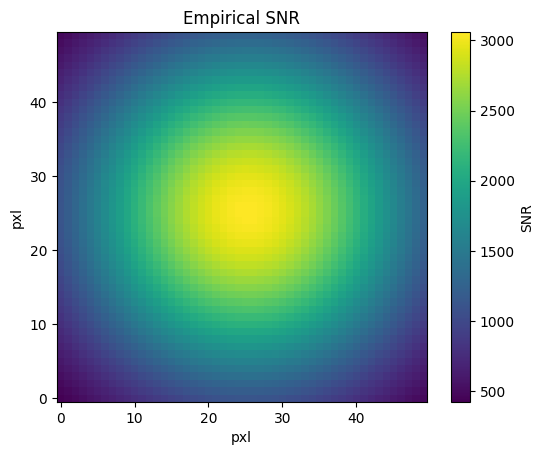

In [ ]:
snr_emp = t*(signal-bg_src)/np.sqrt(t*signal)
# TODO: change the ticks to correspond to the pixel number of the screen
plt.imshow(snr_emp, origin='lower')
plt.colorbar(label="SNR")
plt.title("Empirical SNR")
plt.xlabel('pxl')
plt.ylabel('pxl')

## 2. SNR function with L-band, chop & nod and PSF subtraction included

To have one callable function to determine the SNR without copy/paste every cell each time. 
Adjustment have been made so the function is able to consider L-band observations and chop&nod. 
The file [QE_detector_H2RG_METIS.dat](./ScopeSim/inst_pkgs/METIS/QE_detector_H2RG_METIS.dat) gives QE at 4µm.

See [functions.py](functions.py) for the updated version of the `SNR_calculation` function.